In [59]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import pandas as pd
import numpy as np 
%matplotlib inline


In [60]:
X, y = make_blobs(n_samples=1000, centers=5, n_features=2)

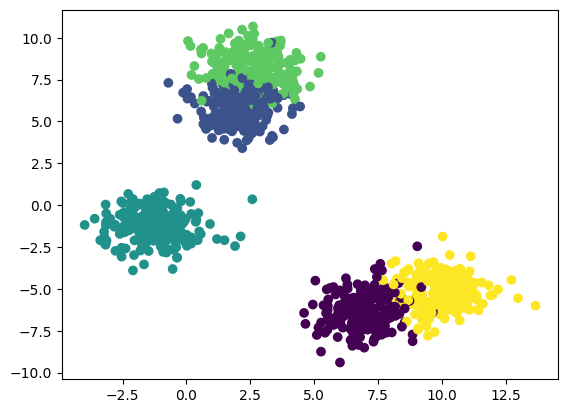

In [61]:
#    
plt.scatter(X[:, 0], X[:,1], c=y)

[1339.999999999999, 350.9836435482847, 110.90178167674145, 68.52625134721293, 53.808258412717535, 47.55506115205455, 41.903400095323256, 39.49763848587861, 32.628657575576355, 29.779476918560363]


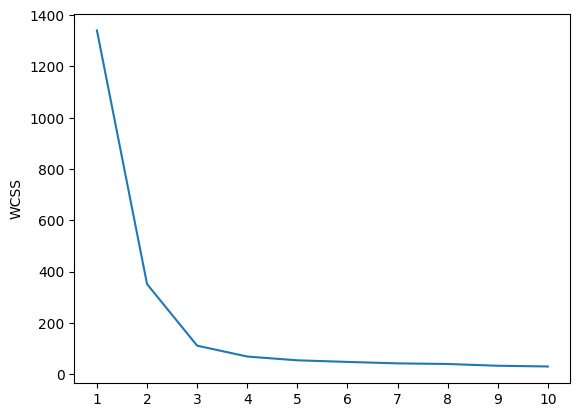

In [62]:
##perform standardization -- feature scaling techniques

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,y, test_size=0.33, random_state=42
)

#feature scalling 
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

from sklearn.cluster import KMeans

##elbow method to select k value

wcss = []  #distance between each and every point with respect to different K values
for k in range(1,11):
    kmeans = KMeans(n_clusters = k, init = "k-means++")
    kmeans.fit(X_train_scaled)
    wcss.append(kmeans.inertia_)

print(wcss)

##plot elbow cjurve 

plt.plot(range(1,11),wcss)

plt.xticks(range(1,11))

plt.ylabel("WCSS")
plt.show()


In [67]:
kmeans = KMeans(n_clusters=5, init="k-means++")
kmeans.fit_predict(X_train_scaled)



array([2, 0, 1, 2, 1, 1, 2, 3, 3, 0, 3, 3, 1, 0, 4, 1, 1, 2, 4, 2, 0, 3,
       1, 4, 0, 1, 3, 3, 3, 0, 1, 1, 0, 0, 3, 3, 4, 3, 3, 1, 0, 3, 2, 1,
       2, 1, 1, 1, 4, 2, 3, 0, 4, 4, 0, 0, 0, 3, 3, 4, 1, 4, 0, 0, 0, 3,
       4, 1, 4, 0, 3, 3, 3, 0, 4, 2, 1, 0, 1, 0, 1, 3, 1, 2, 2, 2, 3, 2,
       1, 3, 3, 1, 4, 0, 2, 3, 2, 0, 3, 2, 0, 2, 2, 3, 4, 2, 1, 1, 2, 1,
       1, 4, 1, 4, 2, 4, 3, 1, 2, 0, 2, 0, 2, 1, 1, 1, 1, 0, 3, 4, 3, 2,
       3, 1, 3, 1, 2, 1, 0, 2, 4, 1, 3, 3, 2, 3, 3, 0, 4, 0, 1, 1, 3, 1,
       4, 2, 4, 2, 1, 3, 3, 2, 4, 1, 4, 2, 0, 3, 2, 3, 3, 1, 2, 0, 3, 0,
       4, 3, 2, 4, 3, 0, 1, 2, 0, 0, 1, 1, 3, 3, 0, 4, 1, 4, 0, 1, 2, 4,
       2, 1, 4, 2, 2, 4, 1, 4, 3, 4, 1, 4, 3, 3, 4, 0, 1, 1, 2, 1, 4, 2,
       0, 4, 3, 0, 2, 3, 3, 3, 4, 0, 3, 1, 2, 1, 1, 4, 2, 3, 2, 2, 1, 4,
       2, 4, 0, 4, 4, 2, 3, 2, 2, 4, 3, 4, 3, 4, 3, 0, 1, 2, 4, 4, 2, 3,
       2, 2, 0, 1, 2, 1, 3, 2, 0, 1, 2, 4, 0, 3, 4, 0, 0, 1, 3, 1, 1, 4,
       0, 4, 2, 2, 4, 3, 2, 2, 1, 4, 1, 0, 4, 1, 0,

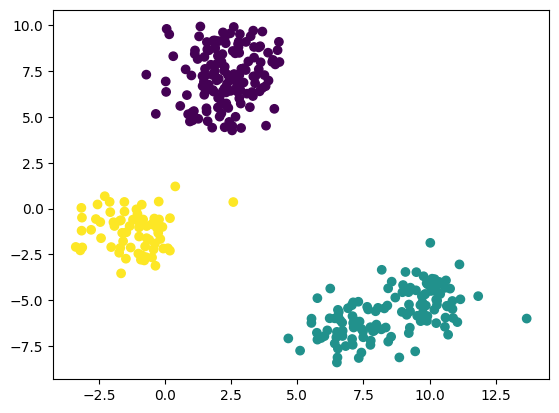

In [64]:
y_pred = kmeans.predict(X_test_scaled)
y_pred

plt.scatter(X_test[:,0], X_test[:,1], c=y_pred)

In [65]:
##validating the k value 
##knee loactor
##silhoutee scoring


#knee locator
# !pip install kneed

from kneed import KneeLocator

kl = KneeLocator(range(1,11), wcss,curve="convex", direction="decreasing")
kl.elbow


##silhoute score

from sklearn.metrics import silhouette_score

silhouette_coefficients=[]
for k in range(3,11):
    kmeans = KMeans(n_clusters=k, init="k-means++")
    kmeans.fit(X_train_scaled)
    score = silhouette_score(X_train_scaled, kmeans.labels_)
    silhouette_coefficients.append(score)

    print(silhouette_coefficients)


[0.7467432932851228]
[0.7467432932851228, 0.6588646286193687]
[0.7467432932851228, 0.6588646286193687, 0.5748824490002833]
[0.7467432932851228, 0.6588646286193687, 0.5748824490002833, 0.44962968201907355]
[0.7467432932851228, 0.6588646286193687, 0.5748824490002833, 0.44962968201907355, 0.43820416123826467]
[0.7467432932851228, 0.6588646286193687, 0.5748824490002833, 0.44962968201907355, 0.43820416123826467, 0.4406164966132037]
[0.7467432932851228, 0.6588646286193687, 0.5748824490002833, 0.44962968201907355, 0.43820416123826467, 0.4406164966132037, 0.41728348542461413]
[0.7467432932851228, 0.6588646286193687, 0.5748824490002833, 0.44962968201907355, 0.43820416123826467, 0.4406164966132037, 0.41728348542461413, 0.3661474685543276]


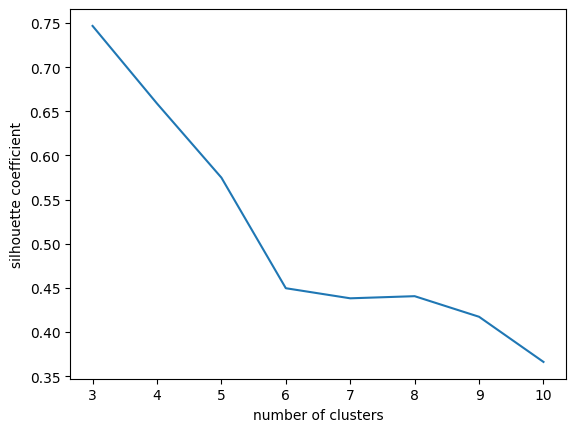

In [70]:
##plotting the silhouette score

plt.plot(range(3,11), silhouette_coefficients)
plt.xticks(range(3,11))
plt.xlabel("number of clusters")
plt.ylabel("silhouette coefficient")
plt.show()